# Vaidya — Layer 1: Exploration

**Goal:** Understand the raw MedMCQA dataset before cleaning.

Steps covered:
- 1.1 Install dependencies
- 1.2 Load dataset and inspect schema, sample rows, missing values, subject distribution

Run on: **Colab free tier** (no GPU needed).

## 1.1 Install dependencies

In [23]:
import sys

IN_COLAB  = 'google.colab' in sys.modules
IN_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in __import__('os').environ

if IN_COLAB or IN_KAGGLE:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                    'datasets', 'pandas', 'pyarrow'], check=True)
else:
    import datasets, pandas
    print(f"Local env OK  |  datasets {datasets.__version__}  pandas {pandas.__version__}")

Local env OK  |  datasets 5.0.1  pandas 2.3.3


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

pd.set_option('display.max_colwidth', 120)

## 1.2 Load MedMCQA

In [25]:
ds = load_dataset("openlifescienceai/medmcqa")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'choice_type', 'exp', 'subject_name', 'topic_name'],
        num_rows: 182822
    })
    test: Dataset({
        features: ['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'choice_type', 'exp', 'subject_name', 'topic_name'],
        num_rows: 6150
    })
    validation: Dataset({
        features: ['id', 'question', 'opa', 'opb', 'opc', 'opd', 'cop', 'choice_type', 'exp', 'subject_name', 'topic_name'],
        num_rows: 4183
    })
})


In [26]:
# Convert to DataFrames for easy inspection
train_df = ds['train'].to_pandas()
val_df   = ds['validation'].to_pandas()
test_df  = ds['test'].to_pandas()

print(f"Train : {len(train_df):,} rows")
print(f"Val   : {len(val_df):,} rows")
print(f"Test  : {len(test_df):,} rows  (labels NOT available — unused)")

Train : 182,822 rows
Val   : 4,183 rows
Test  : 6,150 rows  (labels NOT available — unused)


### Schema

In [27]:
print(train_df.dtypes)
train_df.head(3)

id              object
question        object
opa             object
opb             object
opc             object
opd             object
cop              int64
choice_type     object
exp             object
subject_name    object
topic_name      object
dtype: object


,id,question,opa,opb,opc,opd,cop,choice_type,exp,subject_name,topic_name
0,e9ad821a-c438-4965-9f77-760819dfa155,Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma,Hyperplasia,Hyperophy,Atrophy,Dyplasia,2,single,"Chronic urethral obstruction because of urinary calculi, prostatic hyperophy, tumors, normal pregnancy, tumors, uter...",Anatomy,Urinary tract
1,e3d3c4e1-4fb2-45e7-9f88-247cc8f373b3,Which vitamin is supplied from only animal source:,Vitamin C,Vitamin B7,Vitamin B12,Vitamin D,2,single,Ans. (c) Vitamin B12 Ref: Harrison's 19th ed. P 640* Vitamin B12 (Cobalamin) is synthesized solely by microorganisms...,Biochemistry,Vitamins and Minerals
2,5c38bea6-787a-44a9-b2df-88f4218ab914,All of the following are surgical options for morbid obesity except -,Adjustable gastric banding,Biliopancreatic diversion,Duodenal Switch,Roux en Y Duodenal By pass,3,multi,"Ans. is 'd' i.e., Roux en Y Duodenal Bypass Bariatric surgical procedures include:a. Vertical banded gastroplastyb. ...",Surgery,Surgical Treatment Obesity


Key columns:
- `question` — the MCQ stem
- `opa`, `opb`, `opc`, `opd` — the four answer options
- `cop` — correct option index (0–3 → A–D)
- `subject_name` — medical subject (used for stratified split)
- `exp` — explanation (~40% non-null)
- `choice_type` — `single` or `multi` (we keep only `single`)

### Missing values

In [28]:
key_cols = ['question', 'opa', 'opb', 'opc', 'opd', 'cop', 'subject_name', 'exp', 'choice_type']
null_counts = train_df[key_cols].isnull().sum()
null_pct    = (null_counts / len(train_df) * 100).round(2)
pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})

,null_count,null_%
question,0,0.00
opa,0,0.00
opb,0,0.00
opc,0,0.00
opd,0,0.00
cop,0,0.00
subject_name,0,0.00
exp,21953,12.01
choice_type,0,0.00


### choice_type breakdown

In [29]:
print(train_df['choice_type'].value_counts())
print("\nWe keep only 'single' — multi-choice MCQ format is different.")

choice_type
single    120765
multi      62057
Name: count, dtype: int64

We keep only 'single' — multi-choice MCQ format is different.


### Subject distribution

In [30]:
subject_counts = train_df['subject_name'].value_counts()
print(f"Total subjects: {len(subject_counts)}")
print("\nTop 20:")
print(subject_counts.head(20).to_string())

Total subjects: 21

Top 20:
subject_name
Medicine                        17887
Surgery                         16862
Pathology                       14884
Anatomy                         14560
Pharmacology                    13758
Social & Preventive Medicine    11882
Microbiology                    11314
Gynaecology & Obstetrics        10013
Dental                           8938
Physiology                       8830
Biochemistry                     8282
Pediatrics                       8037
Ophthalmology                    6932
Forensic Medicine                5900
ENT                              4919
Psychiatry                       4442
Radiology                        4395
Anaesthesia                      3172
Unknown                          3045
Orthopaedics                     2999


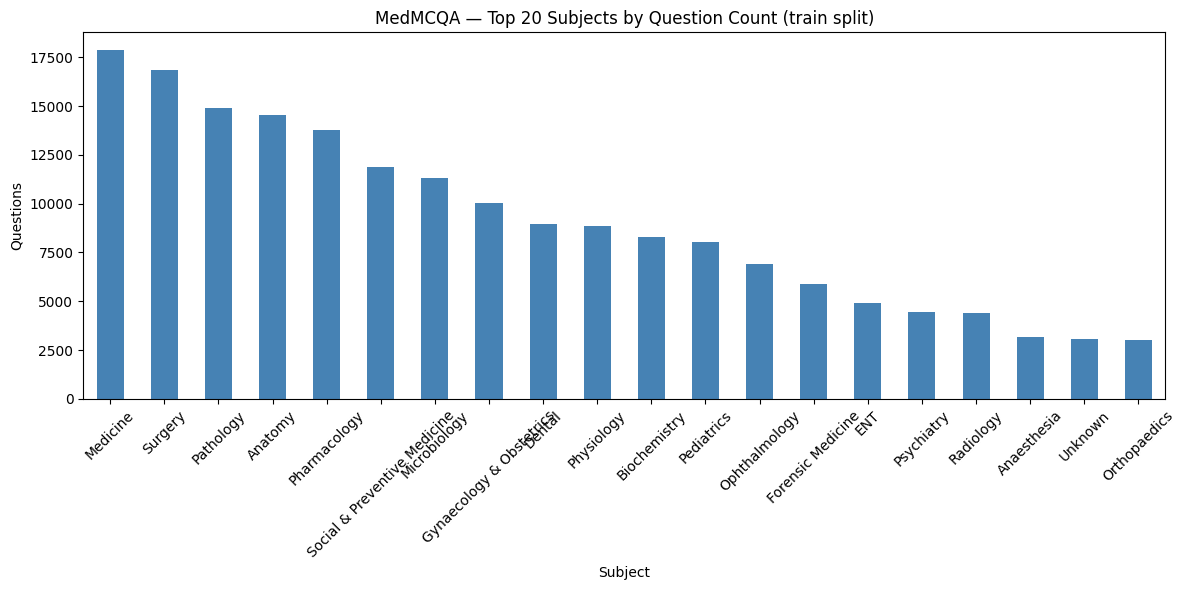

Saved: subject_distribution.png


In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
subject_counts.head(20).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('MedMCQA — Top 20 Subjects by Question Count (train split)')
ax.set_xlabel('Subject')
ax.set_ylabel('Questions')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('subject_distribution.png', dpi=150)
plt.show()
print("Saved: subject_distribution.png")

### Sample rows (with and without explanation)

In [32]:
# Row with explanation
sample_with_exp = train_df[train_df['exp'].notna()].iloc[0]
print("=== Row WITH explanation ===")
for col in key_cols:
    print(f"  {col}: {sample_with_exp[col]}")

print()

# Row without explanation
sample_no_exp = train_df[train_df['exp'].isna()].iloc[0]
print("=== Row WITHOUT explanation ===")
for col in key_cols:
    print(f"  {col}: {sample_no_exp[col]}")

=== Row WITH explanation ===
  question: Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma
  opa: Hyperplasia
  opb: Hyperophy
  opc: Atrophy
  opd: Dyplasia
  cop: 2
  subject_name: Anatomy
  exp: Chronic urethral obstruction because of urinary calculi, prostatic hyperophy, tumors, normal pregnancy, tumors, uterine prolapse or functional disorders cause hydronephrosis which by definition is used to describe dilatation of renal pelvis and calculus associated with progressive atrophy of the kidney due to obstruction to the outflow of urine Refer Robbins 7yh/9,1012,9/e. P950
  choice_type: single

=== Row WITHOUT explanation ===
  question: With which of the following receptors theophylline has an antagonistic interaction ?
  opa: Histamine receptors
  opb: Bradykinin receptors
  opc: Adenosine receptors
  opd: Imidazoline receptors
  cop: 2
  subject_name: Pharmacology
  exp: None
  choice_type: single


### cop → label mapping check

In [33]:
print("cop value distribution:")
print(train_df['cop'].value_counts().sort_index())
print("\nMapping: 0→A, 1→B, 2→C, 3→D")
cop_map = {0: 'A', 1: 'B', 2: 'C', 3: 'D'}
opt_map  = {0: 'opa', 1: 'opb', 2: 'opc', 3: 'opd'}

# Sanity check: verify cop actually points to the right option column
sample = train_df.iloc[5]
correct_col = opt_map[sample['cop']]
print(f"\nSanity check row 5:  cop={sample['cop']} → {cop_map[sample['cop']]} → {correct_col} = '{sample[correct_col]}'")

cop value distribution:
cop
0    53591
1    47826
2    42442
3    38963
Name: count, dtype: int64

Mapping: 0→A, 1→B, 2→C, 3→D

Sanity check row 5:  cop=2 → C → opc = 'Mite'


### Summary

In [34]:
single_train = train_df[train_df['choice_type'] == 'single']
exp_rate = single_train['exp'].notna().mean()

print("=== Exploration Summary ===")
print(f"  Total train rows         : {len(train_df):,}")
print(f"  After keeping 'single'   : {len(single_train):,}")
print(f"  Explanation present      : {exp_rate:.1%}")
print(f"  Unique subjects          : {train_df['subject_name'].nunique()}")
print(f"  Null question rows       : {train_df['question'].isna().sum()}")
print()
print("Ready for notebook 02 — cleaning and formatting.")

=== Exploration Summary ===
  Total train rows         : 182,822
  After keeping 'single'   : 120,765
  Explanation present      : 88.1%
  Unique subjects          : 21
  Null question rows       : 0

Ready for notebook 02 — cleaning and formatting.
